# Notebook 06 - Analyse corrig?e de la vitesse et de la direction

Nous analysons la vitesse et la direction ? partir de la trajectoire liss?e. Cette ?tape ?vite que de petits sauts r?siduels dans la trajectoire brute cr?ent des pics de vitesse ou des directions instables.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "car" / "car-11"
IMG_DIR = DATA_DIR / "img"
RESULTS_DIR = PROJECT_ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "plots"
FRAMES_DIR = RESULTS_DIR / "frames_output"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
FRAMES_DIR.mkdir(parents=True, exist_ok=True)

print("Racine du projet:", PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.trajectory import load_trajectory_csv, smooth_trajectory

Racine du projet: c:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\motion-estimation-project


## Chargement de la trajectoire

Nous chargeons `results/trajectory_estimated.csv`. Si les colonnes liss?es ne sont pas pr?sentes, nous les recalculons avec une m?diane glissante de taille 5.

In [2]:
trajectory_df = load_trajectory_csv(RESULTS_DIR / "trajectory_estimated.csv")
if "center_x_smooth" not in trajectory_df.columns or "center_y_smooth" not in trajectory_df.columns:
    trajectory_df = smooth_trajectory(trajectory_df, window=5)

trajectory_df.head()

,frame_id,center_x,center_y,nb_points,center_x_smooth,center_y_smooth
0,0,624.500000,323.500000,80,615.942383,317.271454
1,1,615.942383,317.094177,34,615.576538,317.408554
2,2,615.210693,317.271454,34,615.210693,317.545654
3,3,614.292725,317.545654,34,614.292725,317.545654
4,4,613.827576,317.665894,34,613.827576,317.665894


## Calcul de dx, dy et vitesse

Nous calculons `dx` et `dy` avec `center_x_smooth` et `center_y_smooth`. La vitesse est exprim?e en pixels/frame, pas en m/s, car nous n'avons pas de calibration m?trique ni d'information temporelle physique.

In [3]:
def interpret_direction(dx, dy, speed):
    if speed < 1:
        return "mouvement tr?s faible ou quasi stable"
    if abs(dx) > 1.5 * abs(dy):
        return "mouvement vers la droite" if dx > 0 else "mouvement vers la gauche"
    if abs(dy) > 1.5 * abs(dx):
        return "mouvement vers le bas" if dy > 0 else "mouvement vers le haut"
    return "mouvement diagonal"

motion_df = trajectory_df.copy()
motion_df["dx"] = motion_df["center_x_smooth"].diff().fillna(0.0)
motion_df["dy"] = motion_df["center_y_smooth"].diff().fillna(0.0)
motion_df["distance"] = np.sqrt(motion_df["dx"] ** 2 + motion_df["dy"] ** 2)
motion_df["speed_px_frame"] = motion_df["distance"]

# Les tr?s grands pics sont consid?r?s comme aberrants, puis interpol?s.
outliers = motion_df["speed_px_frame"] > 50
motion_df.loc[outliers, ["dx", "dy"]] = np.nan
motion_df[["dx", "dy"]] = motion_df[["dx", "dy"]].interpolate(limit_direction="both").fillna(0.0)
motion_df["distance"] = np.sqrt(motion_df["dx"] ** 2 + motion_df["dy"] ** 2)
motion_df["speed_px_frame"] = motion_df["distance"]

outliers = motion_df["speed_px_frame"] > 50
motion_df.loc[outliers, ["distance", "speed_px_frame"]] = np.nan
motion_df[["distance", "speed_px_frame"]] = motion_df[["distance", "speed_px_frame"]].interpolate(limit_direction="both").fillna(0.0)

motion_df["direction_rad"] = np.arctan2(motion_df["dy"], motion_df["dx"])
motion_df["direction_deg"] = np.degrees(motion_df["direction_rad"])
motion_df["interpretation"] = [
    interpret_direction(dx, dy, speed)
    for dx, dy, speed in zip(motion_df["dx"], motion_df["dy"], motion_df["speed_px_frame"])
]

columns = [
    "frame_id",
    "center_x",
    "center_y",
    "center_x_smooth",
    "center_y_smooth",
    "dx",
    "dy",
    "distance",
    "speed_px_frame",
    "direction_rad",
    "direction_deg",
    "interpretation",
]
motion_df = motion_df[columns]
motion_df.to_csv(RESULTS_DIR / "motion_analysis_estimated.csv", index=False)
motion_df.head()

,frame_id,center_x,center_y,center_x_smooth,center_y_smooth,dx,dy,distance,speed_px_frame,direction_rad,direction_deg,interpretation
0,0,624.500000,323.500000,615.942383,317.271454,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,mouvement tr?s faible ou quasi stable
1,1,615.942383,317.094177,615.576538,317.408554,-0.365845,0.137100,0.390690,0.390690,2.783041,159.456526,mouvement tr?s faible ou quasi stable
2,2,615.210693,317.271454,615.210693,317.545654,-0.365845,0.137100,0.390690,0.390690,2.783041,159.456526,mouvement tr?s faible ou quasi stable
3,3,614.292725,317.545654,614.292725,317.545654,-0.917969,0.000000,0.917969,0.917969,3.141593,180.000000,mouvement tr?s faible ou quasi stable
4,4,613.827576,317.665894,613.827576,317.665894,-0.465149,0.120239,0.480438,0.480438,2.888634,165.506516,mouvement tr?s faible ou quasi stable


Nous observons que les vitesses aberrantes sont supprim?es puis interpol?es. Cette ?tape rend la courbe plus interpr?table sans convertir la vitesse en unit?s physiques.

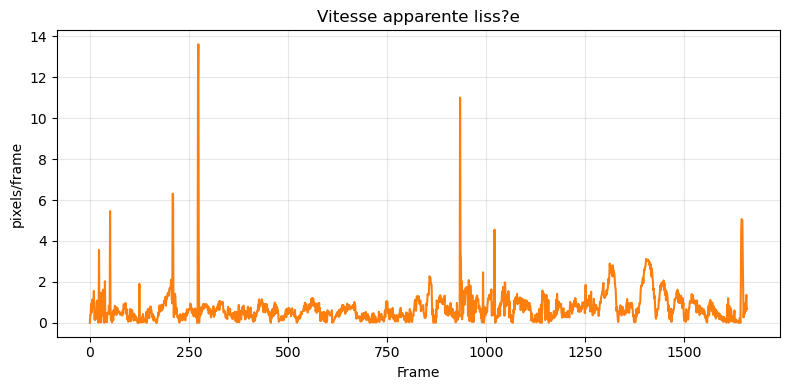

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(motion_df["frame_id"], motion_df["speed_px_frame"], color="tab:orange")
ax.set_title("Vitesse apparente liss?e")
ax.set_xlabel("Frame")
ax.set_ylabel("pixels/frame")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "speed_curve.png", dpi=150, bbox_inches="tight")
plt.show()

Nous interpr?tons la vitesse comme le d?placement apparent du centre liss? entre deux frames successives.

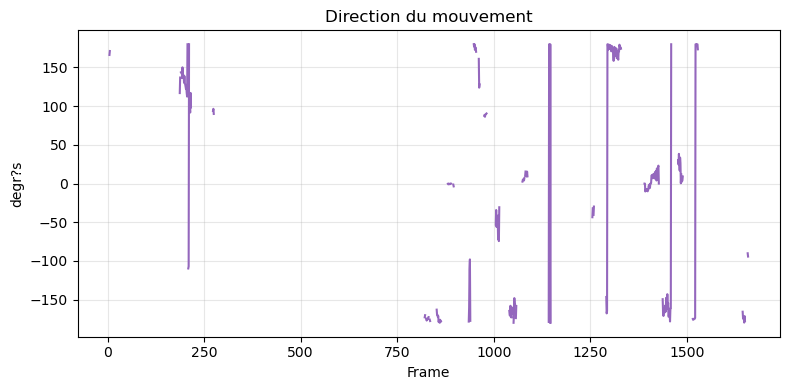

In [5]:
direction_for_plot = motion_df["direction_deg"].where(motion_df["speed_px_frame"] >= 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(motion_df["frame_id"], direction_for_plot, color="tab:purple")
ax.set_title("Direction du mouvement")
ax.set_xlabel("Frame")
ax.set_ylabel("degr?s")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "direction_curve.png", dpi=150, bbox_inches="tight")
plt.show()

Nous calculons la direction avec `atan2(dy, dx)` sur les d?placements liss?s. Lorsque la vitesse est tr?s faible, nous ?vitons d'interpr?ter la direction car un angle devient peu fiable.